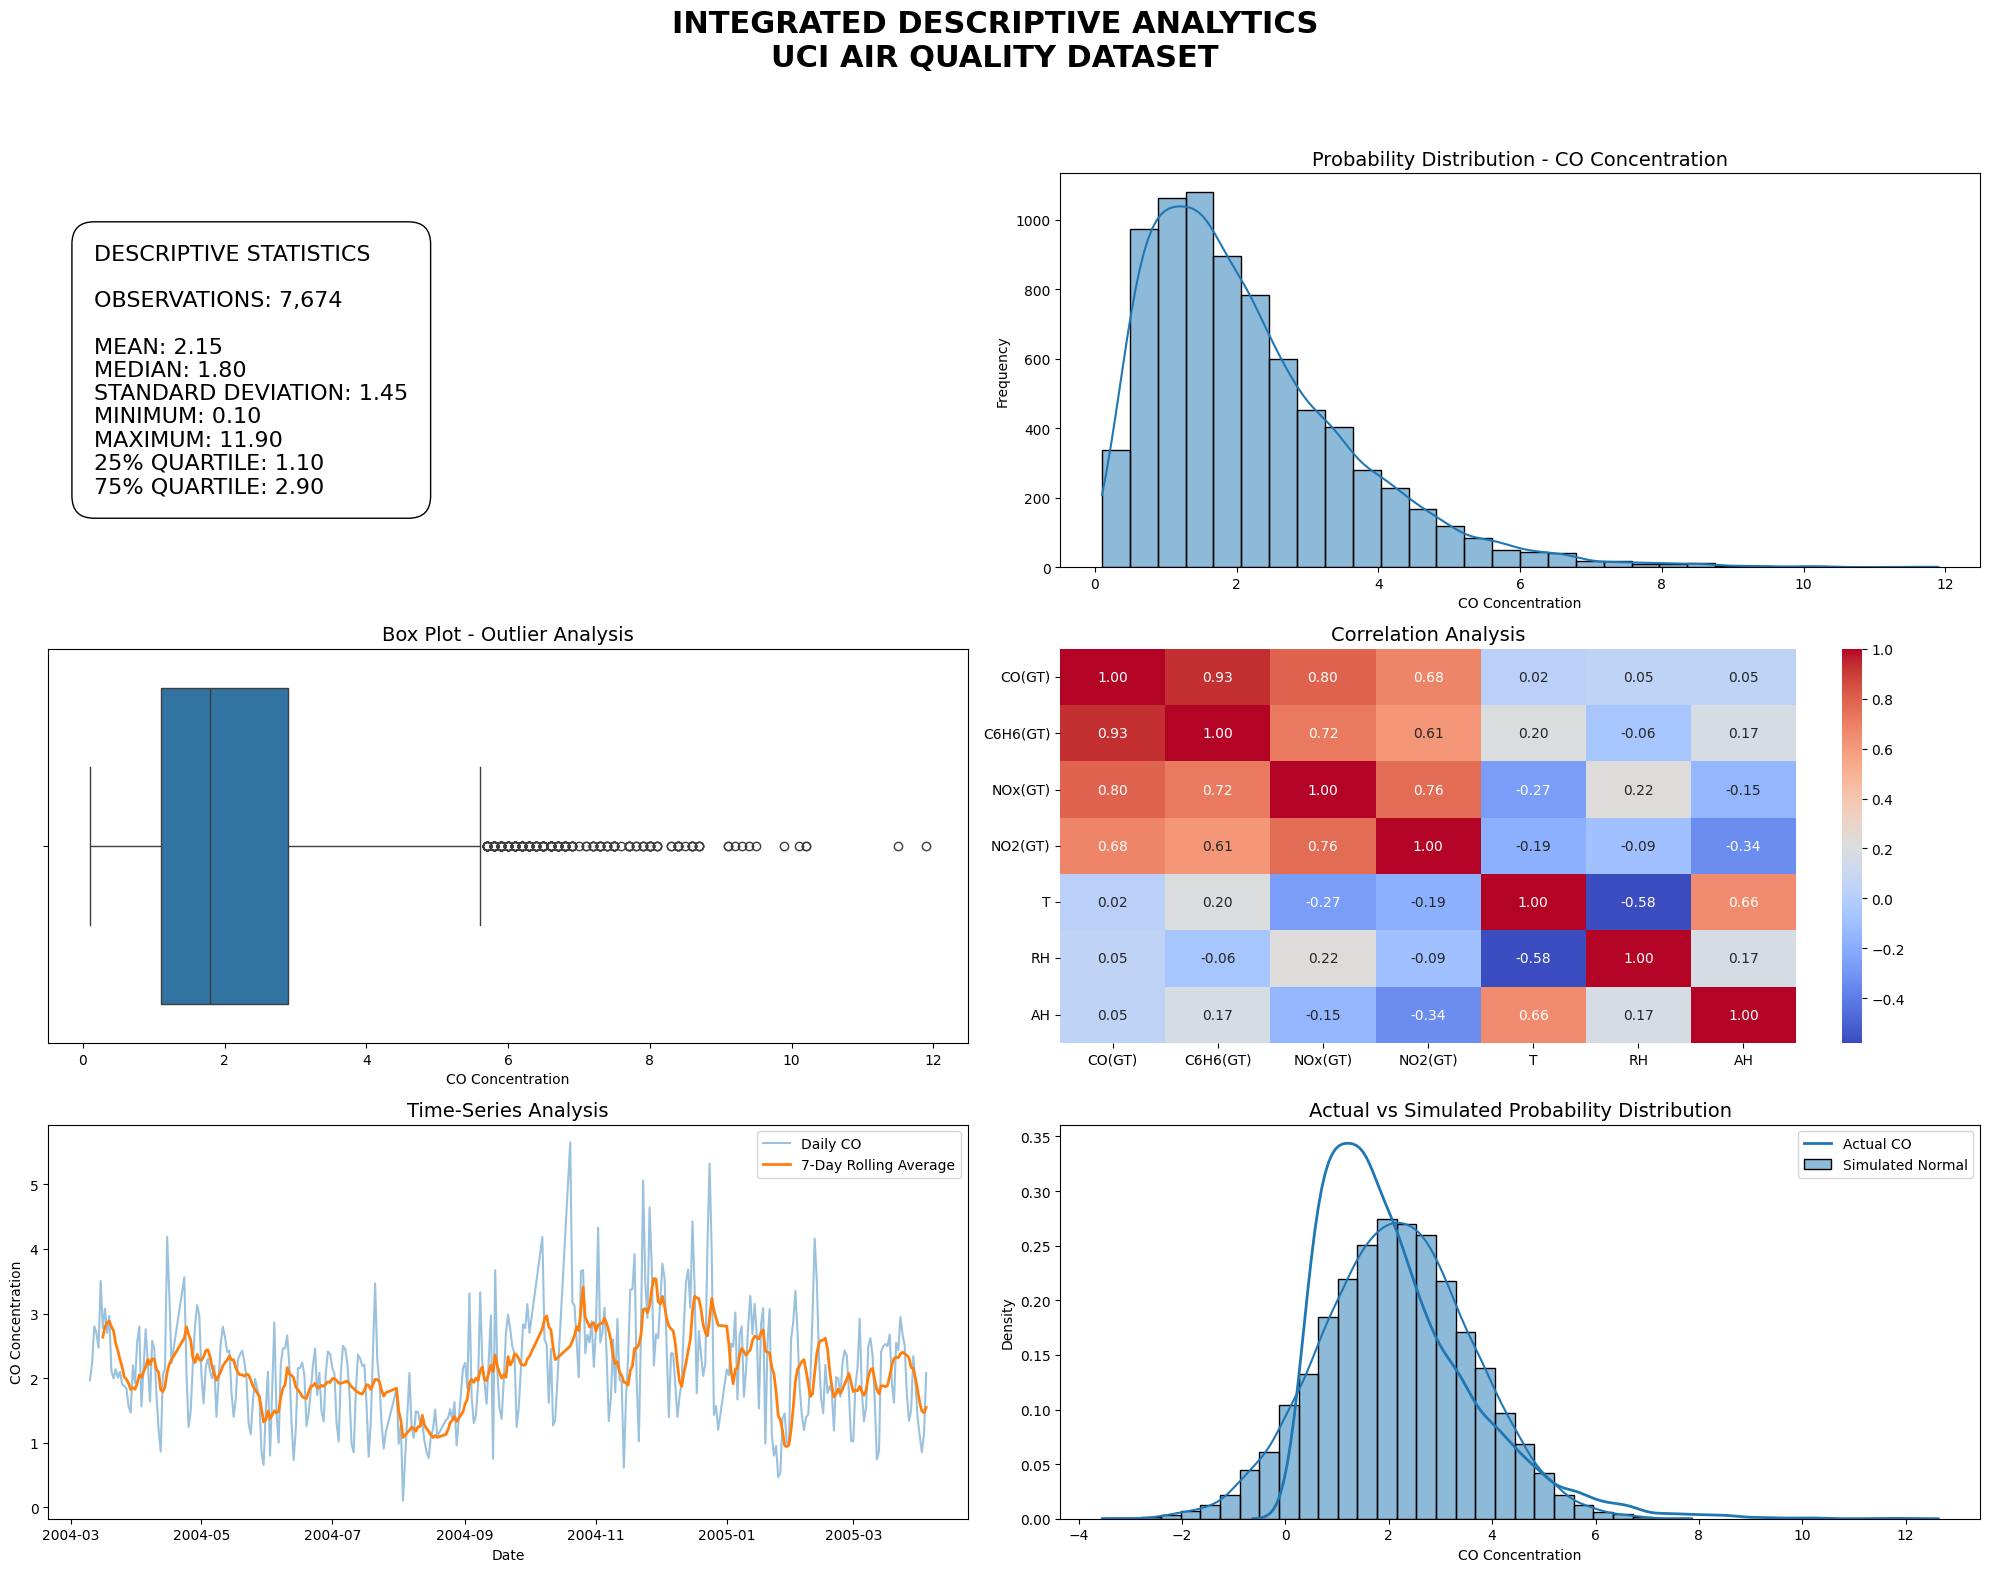

INTEGRATED DESCRIPTIVE ANALYTICS COMPLETED
Original Dataset: UCI Air Quality
Valid CO Observations: 7674
Mean CO: 2.15
Median CO: 1.8
Standard Deviation: 1.45
Minimum CO: 0.1
Maximum CO: 11.9

Requirements completed:
✓ Genuine dataset
✓ Pandas
✓ NumPy
✓ Matplotlib
✓ Seaborn
✓ Descriptive statistics
✓ Data visualization
✓ Probability distribution simulation
✓ Time-series analysis
✓ Google Sheets CSV

CSV file created:
air_quality_google_sheets.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os
from google.colab import files

# ==============================
# 1. DOWNLOAD ORIGINAL UCI DATA
# ==============================
url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
urllib.request.urlretrieve(url, "air_quality.zip")

with zipfile.ZipFile("air_quality.zip", "r") as z:
    z.extractall("air_quality")

# Find CSV file
csv_files = [x for x in os.listdir("air_quality") if x.lower().endswith(".csv")]
csv_path = os.path.join("air_quality", csv_files[0])

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv(
    csv_path,
    sep=";",
    decimal=",",
    encoding="latin1"
)

# Remove completely empty columns
df = df.dropna(axis=1, how="all")

# Replace UCI missing-value code
df = df.replace(-200, np.nan)

# ==============================
# 3. CORRECT DATE + TIME
# ==============================

# Convert Time from 18.00.00 -> 18:00:00
df["Time"] = df["Time"].astype(str).str.replace(".", ":", regex=False)

# Create DateTime using exact format
df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(subset=["DateTime"])

# Sort by time
df = df.sort_values("DateTime")

# Set DateTime index
df = df.set_index("DateTime")

# ==============================
# 4. SELECT CO DATA
# ==============================
co = df["CO(GT)"].dropna()

# Daily average WITHOUT problematic resample
daily = (
    co.groupby(co.index.date)
      .mean()
)

daily.index = pd.to_datetime(daily.index)

# 7-day rolling average
rolling = daily.rolling(7).mean()

# ==============================
# 5. SIMULATE PROBABILITY
# ==============================
np.random.seed(42)

simulated = np.random.normal(
    loc=co.mean(),
    scale=co.std(),
    size=10000
)

# ==============================
# 6. CORRELATION
# ==============================
columns = [
    "CO(GT)",
    "C6H6(GT)",
    "NOx(GT)",
    "NO2(GT)",
    "T",
    "RH",
    "AH"
]

corr = df[columns].corr()

# ==============================
# 7. EXPORT FOR GOOGLE SHEETS
# ==============================
google_sheets_data = df.reset_index()

google_sheets_data.to_csv(
    "air_quality_google_sheets.csv",
    index=False
)

# ==============================
# 8. CREATE ONE COMBINED CHART
# ==============================
fig, ax = plt.subplots(
    3,
    2,
    figsize=(20, 16)
)

fig.suptitle(
    "INTEGRATED DESCRIPTIVE ANALYTICS\nUCI AIR QUALITY DATASET",
    fontsize=22,
    fontweight="bold"
)

# --------------------------------
# CHART 1: DESCRIPTIVE STATISTICS
# --------------------------------
ax[0, 0].axis("off")

statistics_text = (
    f"OBSERVATIONS: {len(co):,}\n\n"
    f"MEAN: {co.mean():.2f}\n"
    f"MEDIAN: {co.median():.2f}\n"
    f"STANDARD DEVIATION: {co.std():.2f}\n"
    f"MINIMUM: {co.min():.2f}\n"
    f"MAXIMUM: {co.max():.2f}\n"
    f"25% QUARTILE: {co.quantile(0.25):.2f}\n"
    f"75% QUARTILE: {co.quantile(0.75):.2f}"
)

ax[0, 0].text(
    0.05,
    0.5,
    "DESCRIPTIVE STATISTICS\n\n" + statistics_text,
    fontsize=16,
    verticalalignment="center",
    bbox=dict(
        boxstyle="round,pad=1",
        facecolor="white",
        edgecolor="black"
    )
)

# --------------------------------
# CHART 2: DISTRIBUTION
# --------------------------------
sns.histplot(
    co,
    bins=30,
    kde=True,
    ax=ax[0, 1]
)

ax[0, 1].set_title(
    "Probability Distribution - CO Concentration",
    fontsize=14
)

ax[0, 1].set_xlabel("CO Concentration")
ax[0, 1].set_ylabel("Frequency")

# --------------------------------
# CHART 3: BOX PLOT
# --------------------------------
sns.boxplot(
    x=co,
    ax=ax[1, 0]
)

ax[1, 0].set_title(
    "Box Plot - Outlier Analysis",
    fontsize=14
)

ax[1, 0].set_xlabel("CO Concentration")

# --------------------------------
# CHART 4: CORRELATION HEATMAP
# --------------------------------
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax[1, 1]
)

ax[1, 1].set_title(
    "Correlation Analysis",
    fontsize=14
)

# --------------------------------
# CHART 5: TIME SERIES
# --------------------------------
ax[2, 0].plot(
    daily.index,
    daily.values,
    alpha=0.45,
    label="Daily CO"
)

ax[2, 0].plot(
    rolling.index,
    rolling.values,
    linewidth=2,
    label="7-Day Rolling Average"
)

ax[2, 0].set_title(
    "Time-Series Analysis",
    fontsize=14
)

ax[2, 0].set_xlabel("Date")
ax[2, 0].set_ylabel("CO Concentration")
ax[2, 0].legend()

# --------------------------------
# CHART 6: ACTUAL VS SIMULATED
# --------------------------------
sns.histplot(
    simulated,
    bins=30,
    stat="density",
    kde=True,
    ax=ax[2, 1],
    label="Simulated Normal"
)

sns.kdeplot(
    co,
    ax=ax[2, 1],
    linewidth=2,
    label="Actual CO"
)

ax[2, 1].set_title(
    "Actual vs Simulated Probability Distribution",
    fontsize=14
)

ax[2, 1].set_xlabel("CO Concentration")
ax[2, 1].set_ylabel("Density")
ax[2, 1].legend()

# ==============================
# FINAL DISPLAY
# ==============================
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "integrated_descriptive_analytics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==============================
# RESULTS
# ==============================
print("=" * 60)
print("INTEGRATED DESCRIPTIVE ANALYTICS COMPLETED")
print("=" * 60)

print("Original Dataset: UCI Air Quality")
print("Valid CO Observations:", len(co))
print("Mean CO:", round(co.mean(), 2))
print("Median CO:", round(co.median(), 2))
print("Standard Deviation:", round(co.std(), 2))
print("Minimum CO:", round(co.min(), 2))
print("Maximum CO:", round(co.max(), 2))

print("\nRequirements completed:")
print("✓ Genuine dataset")
print("✓ Pandas")
print("✓ NumPy")
print("✓ Matplotlib")
print("✓ Seaborn")
print("✓ Descriptive statistics")
print("✓ Data visualization")
print("✓ Probability distribution simulation")
print("✓ Time-series analysis")
print("✓ Google Sheets CSV")

print("\nCSV file created:")
print("air_quality_google_sheets.csv")

# Download CSV
files.download("air_quality_google_sheets.csv")